In [15]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
# Загрузка данных
data = pd.read_csv('data.csv')

In [21]:
# Базовый обзор датасета
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       500 non-null    int64  
 1   Priority                 500 non-null    int64  
 2   Systems                  500 non-null    int64  
 3   Integrations             500 non-null    int64  
 4   Enterprise architecture  500 non-null    str    
 5   Technical debt           500 non-null    bool   
 6   PM                       490 non-null    str    
 7   Days                     500 non-null    int64  
 8   Effort                   5 non-null      float64
dtypes: bool(1), float64(1), int64(5), str(2)
memory usage: 27.9 KB


In [22]:
# Первые 5 строк для понимания данных в колонках
'''
Сразу видно категориальные переменные
'Enterprise architecture', 'Technical debt', 'PM'
И числовые
'Priority', 'Systems', 'Integrations'

Поле Id не несет в себе полезной нагрузки и выглядит избыточным - на удаление
Поле Effort имеет 99% пропусков и в таком виде ничем не помогает - на удаление
'''
data.head()

,Id,Priority,Systems,Integrations,Enterprise architecture,Technical debt,PM,Days,Effort
0,893819,2,1,1,in progress,False,Andrei H,153,NaN
1,893820,2,2,6,in progress,True,Elena A,186,NaN
2,893821,1,2,2,in progress,True,Ksenia G,107,NaN
3,893822,2,3,7,new,False,Andrei H,186,NaN
4,893823,1,2,6,done,False,Ksenia G,92,NaN


In [23]:
# Подготовка данных для моделирования
# Удаляю ненужные столбцы
data = data.drop('Id', axis = 1)
data = data.drop('Effort', axis = 1)
# Разделение признаков
# т.к. 'Technical debt' содержит bool - привожу тип
categorical_cols = ['Enterprise architecture', 'Technical debt', 'PM']
numeric_cols = ['Priority', 'Systems', 'Integrations']
for col in categorical_cols:
    data[col] = data[col].astype(str)

In [24]:
# Создание пайплайна и препроцессинг
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # для заполнения пропусков
    ('scaler', StandardScaler()) # шкалирование данных для единообразия
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # для заполнения пропусков
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # преобразование категориальных
])

In [25]:
# Объединяю
preprocessor = ColumnTransformer(
    transformers=[
        ('Numerical', numeric_transformer, numeric_cols),
        ('Categorical', categorical_transformer, categorical_cols)
    ])

# Добавляю в ансамбль из kNN и Forest
ensemble = VotingRegressor(estimators=[
    ('knn', KNeighborsRegressor()),
    ('rf', RandomForestRegressor(random_state=42))
])

# Финализация пайплайна
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ensemble', ensemble)
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('ensemble', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numerical', ...), ('Categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [26]:
# Разделение на train/test
'''
т.к. датасет небольшой, то решил оставить на тест 20%
'''
X = data.drop('Days', axis=1)
y = data['Days']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (400, 6)  Test: (100, 6)


In [27]:
# Подбор гиперпараметров моделей
param_grid = {
    'ensemble__knn__n_neighbors': [3, 5, 7], # количество соседей
    'ensemble__knn__weights': ['uniform', 'distance'], # с одинаковым и обратнопропорциональным весом
    'ensemble__rf__n_estimators': [100, 200], # количество деревьев решений 
    'ensemble__rf__max_depth': [None, 10, 20] # максимальная глубина каждого дерева
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...tate=42))]))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ensemble__knn__n_neighbors': [3, 5, ...], 'ensemble__knn__weights': ['uniform', 'distance'], 'ensemble__rf__max_depth': [None, 10, ...], 'ensemble__rf__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more message

In [33]:
# Отчет по метрикам на подобранных гиперпараметрах
'''
По результатам получил, что для ансамбля из kNN и RandomForest
MAE - среднее отклонение - на 6.3885
R2 - эффективность по количеству отклонений в прогнозах - 0.9830
'''
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

report = pd.DataFrame({
    'Метрика': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Значение': [round(mae, 4), round(mse, 4), round(rmse, 4), round(r2, 4)]
})

print(report.to_string(index=False))
print('\n')
print(f'Лучшие гиперпараметры:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print('\n')
print(f'R2 на кросс-валидации: {grid_search.best_score_:.4f}')

Метрика  Значение
    MAE    6.3885
    MSE  157.3878
   RMSE   12.5454
     R2    0.9830


Лучшие гиперпараметры:
  ensemble__knn__n_neighbors: 3
  ensemble__knn__weights: distance
  ensemble__rf__max_depth: 10
  ensemble__rf__n_estimators: 200


R2 на кросс-валидации: 0.9847


RandomForestRegressor
Метрика  Значение
    MAE    3.6197
    MSE   45.0832
   RMSE    6.7144
     R2    0.9951
Лучшие параметры RF : {'max_depth': 10, 'n_estimators': 200}


KNeighborsRegressor
Метрика  Значение
    MAE   10.8314
    MSE  546.5783
   RMSE   23.3790
     R2    0.9408
Лучшие параметры KNN: {'n_neighbors': 3, 'weights': 'distance'}


СВОДНОЕ СРАВНЕНИЕ МОДЕЛЕЙ
                     model     MAE      MSE    RMSE     R2
     RandomForestRegressor  3.6197  45.0832  6.7144 0.9951
       KNeighborsRegressor 10.8314 546.5783 23.3790 0.9408
VotingRegressor (ансамбль)  6.3885 157.3878 12.5454 0.9830




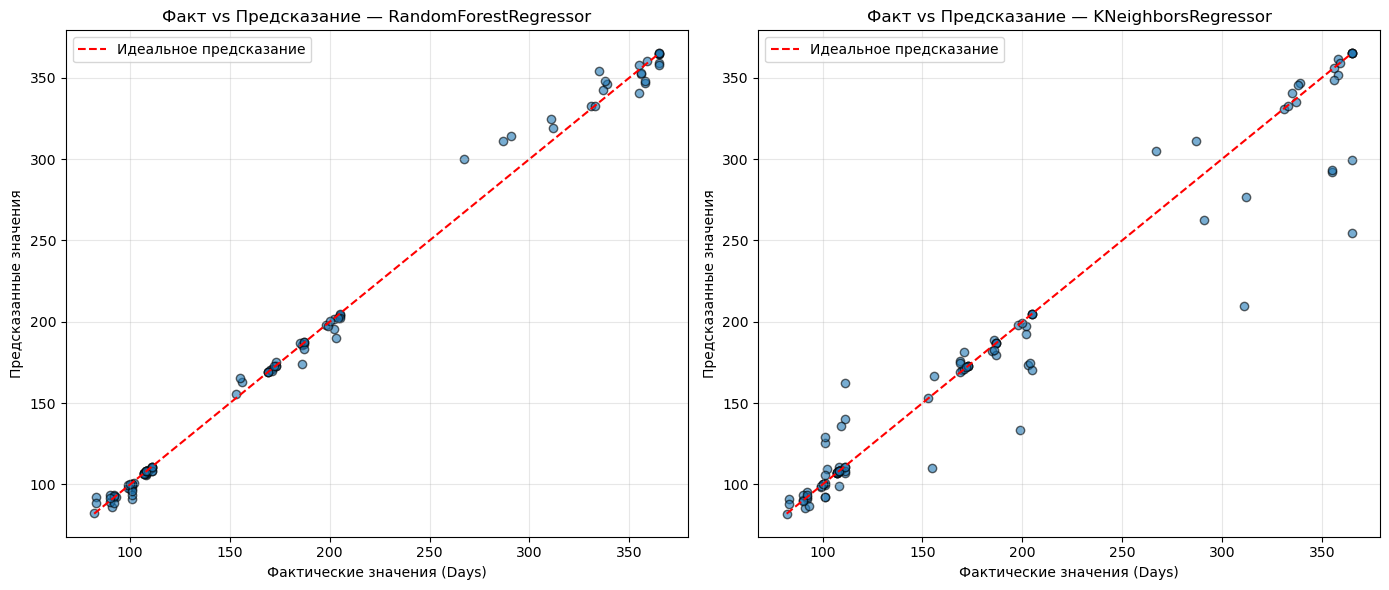


Важность признаков (RandomForestRegressor):
                                         Признак  Важность
                             Numerical__Priority  0.976957
                              Numerical__Systems  0.013560
                Categorical__Technical debt_True  0.001862
               Categorical__Technical debt_False  0.001854
       Categorical__Enterprise architecture_done  0.001817
                         Numerical__Integrations  0.000982
                        Categorical__PM_Andrei M  0.000712
                        Categorical__PM_Ksenia G  0.000684
                         Categorical__PM_Elena A  0.000494
                        Categorical__PM_Andrei H  0.000479
        Categorical__Enterprise architecture_new  0.000385
Categorical__Enterprise architecture_in progress  0.000214


In [38]:
# Но хочется еще все-таки посмотреть в отдельности каждую из моделей

best_params = grid_search.best_params_

knn_params = {
    k.replace('ensemble__knn__', ''): v
    for k, v in best_params.items()
    if k.startswith('ensemble__knn__')
}

rf_params = {
    k.replace('ensemble__rf__', ''): v
    for k, v in best_params.items()
    if k.startswith('ensemble__rf__')
}

# Универсальная функция для расчета и отчета
def evaluate_model(name, estimator, X_tr, y_tr, X_te, y_te):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])
    pipe.fit(X_tr, y_tr)
    y_hat = pipe.predict(X_te)

    mae_  = mean_absolute_error(y_te, y_hat)
    mse_  = mean_squared_error(y_te, y_hat)
    rmse_ = np.sqrt(mse_)
    r2_   = r2_score(y_te, y_hat)

    rep = pd.DataFrame({
        'Метрика':  ['MAE', 'MSE', 'RMSE', 'R2'],
        'Значение': [round(mae_, 4), round(mse_, 4),
                     round(rmse_, 4), round(r2_, 4)]
    })

    print(f'{name}')
    print(rep.to_string(index=False))

    return pipe, y_hat, {'model': name, 'MAE': mae_, 'MSE': mse_,
                         'RMSE': rmse_, 'R2': r2_}


# Модели RandomForest и kNN в отдельности
rf_model = RandomForestRegressor(random_state=42, **rf_params)
knn_model = KNeighborsRegressor(**knn_params)

rf_pipe,  rf_pred,  rf_metrics  = evaluate_model(
    'RandomForestRegressor', rf_model, X_train, y_train, X_test, y_test)
print('Лучшие параметры RF :', rf_params)
print('\n')

knn_pipe, knn_pred, knn_metrics = evaluate_model(
    'KNeighborsRegressor',   knn_model, X_train, y_train, X_test, y_test)
print('Лучшие параметры KNN:', knn_params)
print('\n')

# Сводная сравнительная таблица
ensemble_metrics = {'model': 'VotingRegressor (ансамбль)',
                    'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

comparison = pd.DataFrame([rf_metrics, knn_metrics, ensemble_metrics])
comparison = comparison[['model', 'MAE', 'MSE', 'RMSE', 'R2']].round(4)


print('СВОДНОЕ СРАВНЕНИЕ МОДЕЛЕЙ')
print(comparison.to_string(index=False))
print('\n')


# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (title, y_hat) in zip(
        axes, [('RandomForestRegressor', rf_pred),
               ('KNeighborsRegressor',   knn_pred)]):
    ax.scatter(y_test, y_hat, alpha=0.6, edgecolor='k')
    lims = [min(y_test.min(), y_hat.min()),
            max(y_test.max(), y_hat.max())]
    ax.plot(lims, lims, 'r--', label='Идеальное предсказание')
    ax.set_xlabel('Фактические значения (Days)')
    ax.set_ylabel('Предсказанные значения')
    ax.set_title(f'Факт vs Предсказание — {title}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Важность признаков в RandomForest
feature_names = rf_pipe.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipe.named_steps['model'].feature_importances_

fi = (pd.DataFrame({'Признак': feature_names, 'Важность': importances})
        .sort_values('Важность', ascending=False)
        .reset_index(drop=True))

print('\nВажность признаков (RandomForestRegressor):')
print(fi.to_string(index=False))


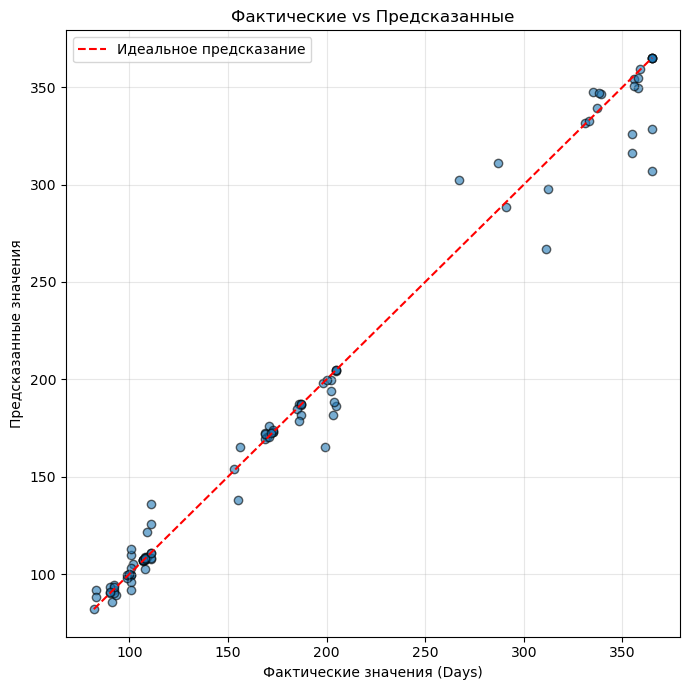

In [39]:
# Визуальное сравнение фактических и предсказанных значений ансамбля
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor='k')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Идеальное предсказание')
plt.xlabel('Фактические значения (Days)')
plt.ylabel('Предсказанные значения')
plt.title('Фактические vs Предсказанные')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()